# 02 — Event Study
This notebook slices a ±90 day window around each geopolitical event and 
calculates how oil prices responded. 

For each event we calculate:
- Price on event day (T=0)
- % change at T+1, T+3, T+7, T+14, T+30, T+60, T+90
- Days to peak price
- Days until price returned within 5% of pre-event level

**Input:** `outputs/master_prices.csv`  
**Output:** `outputs/event_metrics.csv`

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load master dataset
master = pd.read_csv('../outputs/master_prices.csv', parse_dates=['date'])
master = master.set_index('date')

# Load events
events = pd.read_csv('../data/events.csv', parse_dates=['date'])

print(master.head())
print(events)

            brent    wti    gas name type
date                                     
1993-04-05  18.95  20.59  1.068  NaN  NaN
1993-04-06  18.65  20.33  1.068  NaN  NaN
1993-04-07  18.70  20.35  1.068  NaN  NaN
1993-04-08  18.53  20.22  1.068  NaN  NaN
1993-04-12  18.53  20.43  1.079  NaN  NaN
   event_id                   name       date        region       type
0         1        Oil price crash 1999-02-01        Global      crash
1         2           9/11 attacks 2001-09-11           USA  terrorism
2         3          Iraq invasion 2003-03-20   Middle East   invasion
3         4        Libya civil war 2011-02-17  North Africa  civil war
4         5       Ukraine invasion 2022-02-24        Europe   invasion
5         6    Israel-Iran strikes 2025-06-13   Middle East    strikes
6         7  US-Israel war on Iran 2026-03-02   Middle East        war
7         8  2008 Financial Crisis 2008-07-03        Global  financial


## Event Study Function
For each event, we slice a ±90 day window and compute key price metrics.
The base price is indexed to 100 at T=0 so all events are directly comparable.

In [2]:
def event_study(master, event_date, event_name, price_col='brent', window=90):
    start = event_date - pd.Timedelta(days=window)
    end = event_date + pd.Timedelta(days=window)

    slice_df = master.loc[start:end, [price_col]].copy()

    if event_date not in master.index:
        nearest_idx = master.index.get_indexer([event_date], method='nearest')[0]
        base_price = master.iloc[nearest_idx][price_col]
    else:
        base_price = master.loc[event_date, price_col]

    slice_df['t'] = (slice_df.index - event_date).days
    slice_df['indexed'] = (slice_df[price_col] / base_price) * 100
    slice_df['event_name'] = event_name

    return slice_df

# Test on one event
test = event_study(master, pd.Timestamp('2001-09-11'), '9/11 Attack')
print(test.head(10))

            brent   t     indexed   event_name
date                                          
2001-06-13  29.13 -90  100.034341  9/11 Attack
2001-06-14  28.50 -89   97.870879  9/11 Attack
2001-06-15  28.13 -88   96.600275  9/11 Attack
2001-06-18  27.61 -85   94.814560  9/11 Attack
2001-06-19  26.68 -84   91.620879  9/11 Attack
2001-06-20  26.24 -83   90.109890  9/11 Attack
2001-06-21  26.70 -82   91.689560  9/11 Attack
2001-06-22  26.86 -81   92.239011  9/11 Attack
2001-06-25  27.36 -78   93.956044  9/11 Attack
2001-06-26  27.66 -77   94.986264  9/11 Attack


## Run Event Study for All Events
We loop through every event in our events table and combine the results 
into a single DataFrame for plotting and analysis.

In [3]:
results = []

for _, row in events.iterrows():
    study = event_study(master, row['date'], row['name'])
    results.append(study)

all_events = pd.concat(results)
print(all_events['event_name'].value_counts())

event_name
9/11 attacks             129
Ukraine invasion         128
Israel-Iran strikes      128
2008 Financial Crisis    128
Iraq invasion            127
Oil price crash          126
Libya civil war          126
US-Israel war on Iran     83
Name: count, dtype: int64


## Compute Summary Metrics
For each event we extract key statistics: price at T=0, % change at 
various intervals, days to peak, and days to recovery. This table 
becomes the backbone of the Tableau dashboard.

**Note on `days_to_recovery`:** This metric is only calculated for events 
where prices spiked more than 10% above the base price. For events where 
prices dropped immediately (e.g. 9/11, Iraq invasion) recovery is marked 
as None since there was no upward spike to recover from.

In [4]:
def compute_metrics(master, event_date, event_name, price_col='brent'):
    if event_date not in master.index:
        nearest_idx = master.index.get_indexer([event_date], method='nearest')[0]
        base = master.iloc[nearest_idx][price_col]
    else:
        base = master.loc[event_date, price_col]

    def pct_at(days):
        target = event_date + pd.Timedelta(days=days)
        nearest_idx = master.index.get_indexer([target], method='nearest')[0]
        price = master.iloc[nearest_idx][price_col]
        return round((price / base - 1) * 100, 2)

    window = master.loc[event_date:event_date + pd.Timedelta(days=90), price_col]
    peak_price = window.max()
    days_to_peak = (window.idxmax() - event_date).days

    # Only calculate recovery for upward spike events (peak > 10% above base)
    if (peak_price / base - 1) > 0.10:
        peak_date = window.idxmax()
        window_after_peak = master.loc[peak_date:event_date + pd.Timedelta(days=90), price_col]
        recovered = window_after_peak[window_after_peak <= base * 1.05]
        days_to_recovery = (recovered.index[0] - event_date).days if len(recovered) > 0 else None
    else:
        days_to_recovery = None

    return {
        'event': event_name,
        'date': event_date,
        'base_price': round(base, 2),
        'pct_t1': pct_at(1),
        'pct_t7': pct_at(7),
        'pct_t14': pct_at(14),
        'pct_t30': pct_at(30),
        'pct_t90': pct_at(90),
        'peak_price': round(peak_price, 2),
        'peak_pct': round((peak_price / base - 1) * 100, 2),
        'days_to_peak': days_to_peak,
        'days_to_recovery': days_to_recovery
    }

## Save Metrics Table
Export the event metrics to CSV for use in the Tableau dashboard.

In [5]:
metrics = pd.DataFrame([
    compute_metrics(master, row['date'], row['name'])
    for _, row in events.iterrows()
])

metrics.to_csv('../outputs/event_metrics.csv', index=False)
print(metrics.to_string())

                   event       date  base_price  pct_t1  pct_t7  pct_t14  pct_t30  pct_t90  peak_price  peak_pct  days_to_peak  days_to_recovery
0        Oil price crash 1999-02-01       10.81   -3.89   -7.77    -7.77     0.00    52.17       16.53     52.91            87               NaN
1           9/11 attacks 2001-09-11       29.12   -3.02   -5.43   -30.87   -26.58   -38.08       29.22      0.34             3               NaN
2          Iraq invasion 2003-03-20       28.00   -8.61   -2.54    -4.46    -8.00    -5.61       28.97      3.46            83               NaN
3        Libya civil war 2011-02-17      103.45   -1.21   10.11    10.60    10.32     8.79      126.64     22.42            74               NaN
4       Ukraine invasion 2022-02-24      101.29   -2.70   13.89    13.08    21.11    14.93      133.18     31.48            12              19.0
5    Israel-Iran strikes 2025-06-13       76.00    0.00    3.59    -8.72    -6.63   -11.51       80.37      5.75             6    

## Sanity Check — Full History Chart
We plot the full Brent price history with each geopolitical event marked 
as a vertical line. This lets us visually confirm that price spikes align 
with events and identify any obvious data gaps or outliers.

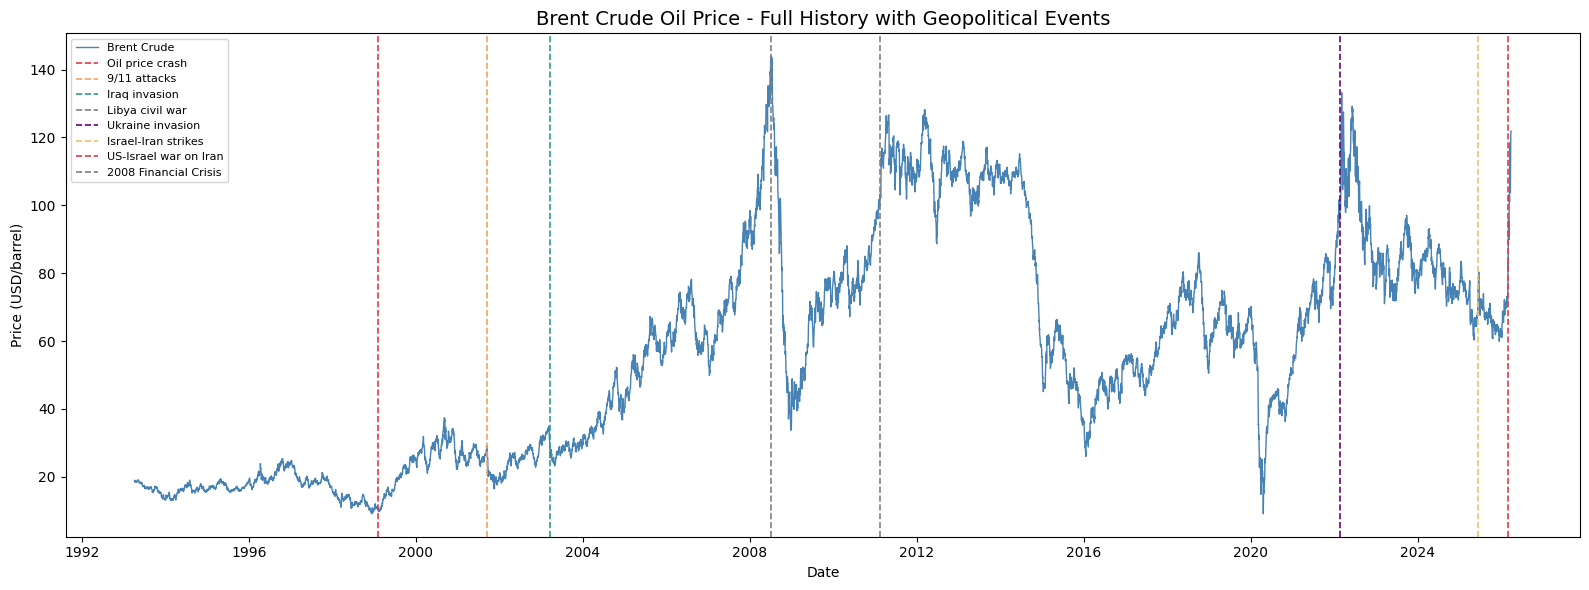

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

# Plot full Brent price history
ax.plot(master.index, master['brent'], color='steelblue', linewidth=1, label='Brent Crude')

# Add vertical lines for each event
colors = {
    'Oil price crash': '#e63946',
    '9/11 attacks': '#f4a261',
    'Iraq invasion': "#2a9d8f",
    'Libyan civil war': '#457b9d',
    'Ukraine invasion': '#6a0572',
    'Israel-Iran strikes': '#e9c46a',
    'US-Israel war on Iran': '#e63946'
}

for _, row in events.iterrows():
    ax.axvline(row['date'],
               color=colors.get(row['name'], 'gray'),
               linestyle='--',
               linewidth=1.2,
               label=row['name'])
    
ax.set_title('Brent Crude Oil Price - Full History with Geopolitical Events', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/sanity_check_chart.png', dpi=150)
plt.show()

## Sanity Check Analysis

**Do the spikes visually line up with the events?**
Yes — key events align well with visible price movements:
- The Oil price crash (1999) correctly marks the bottom of a prolonged slump
- 9/11 and Iraq invasion show modest short-term dips — the market had already 
  priced in geopolitical risk
- Libya (2011) and Ukraine (2022) both show clear upward spikes at the event line
- The 2008 Financial Crisis line lands precisely at the all-time peak of ~$145 
  before the dramatic crash

**Any obvious data gaps or outliers?**
- The 2020 COVID crash (prices briefly went negative) is visible but unmarked — 
  not relevant to geopolitical shocks so intentionally excluded
- No significant data gaps detected across the full 1993–2026 range

**Does the Iran 2026 spike look proportional compared to history?**
The current spike to ~$77 on March 2 appears modest compared to the 2008 
and 2011 peaks — reflecting that the market opened pricing in a severe but 
not yet catastrophic disruption. The scenario projections in `03_iran_2026` 
model how this could develop.

## Overlay Chart — All Crises Aligned at T=0
We plot all events on a single chart with T=0 as the event day and prices 
normalized to 100. This allows direct comparison of the speed and magnitude 
of each shock. The Iran 2026 event is highlighted as the hero line.

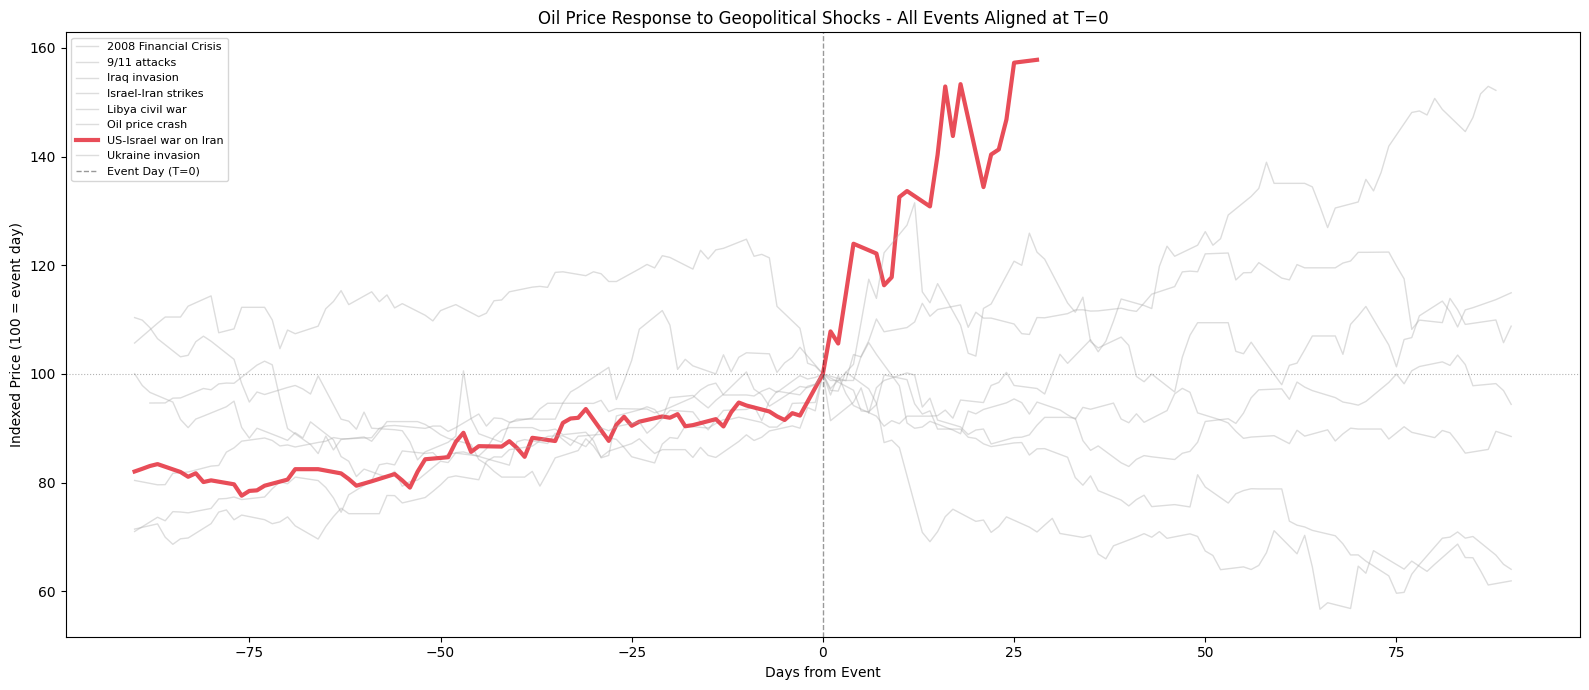

In [7]:
fig, ax = plt.subplots(figsize=(16, 7))

colors = {
    'Oil price crash':          '#aaaaaa',
    '9/11 attacks':             '#aaaaaa',
    'Iraq invasion':            '#aaaaaa',
    'Libya civil war':          '#aaaaaa',
    'Ukraine invasion':         '#aaaaaa',
    'Israel-Iran strikes':      '#aaaaaa',
    '2008 Financial Crisis':    '#aaaaaa',
    'US-Israel war on Iran':    '#e63946'
}

linewidths = {
    'US-Israel war on Iran': 3,
}

for event_name, group in all_events.groupby('event_name'):
    lw = linewidths.get(event_name, 1)
    alpha = 0.9 if event_name == "US-Israel war on Iran" else 0.4
    ax.plot(group['t'], group['indexed'],
            label=event_name,
            color=colors.get(event_name, '#aaaaaa'),
            linewidth=lw,
            alpha=alpha)

ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.4, label= 'Event Day (T=0)')
ax.axhline(100, color='black', linestyle=':', linewidth=0.8, alpha=0.3)
ax.set_xlabel('Days from Event')
ax.set_ylabel('Indexed Price (100 = event day)')
ax.set_title('Oil Price Response to Geopolitical Shocks - All Events Aligned at T=0')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/event_study_chart.png', dpi=150)
plt.show()

In [8]:
print(metrics[metrics['event'] == 'US-Israel war on Iran'].to_string())

                   event       date  base_price  pct_t1  pct_t7  pct_t14  pct_t30  pct_t90  peak_price  peak_pct  days_to_peak  days_to_recovery
6  US-Israel war on Iran 2026-03-02       77.24    7.82   22.15    30.81    57.79    57.79      121.88     57.79            28               NaN


## Overlay Chart Analysis
Each line represents oil prices normalized to 100 at the event date (T=0), 
allowing direct comparison of shock magnitude and speed across all events.

**Key findings:**
- The Iran 2026 line (red) is the steepest post-event spike in the dataset — 
  rising to ~125 indexed within just 7 days, faster and sharper than any 
  other event including Ukraine 2022
- Prices peaked at $95.74 in just 4 days — nearly 3x faster than the Ukraine 
  invasion which was previously the fastest shock in the dataset at 12 days
- The grey lines show significant divergence after T=0 — some events caused 
  sustained spikes (Libya, Ukraine) while others saw immediate reversals (9/11, Iraq)
- The 2008 Financial Crisis stands out as the most extreme post-event drop — 
  prices collapsed nearly 70% within 90 days of the peak
- Most events show prices were already moving in the 30 days BEFORE the event — 
  suggesting markets price in geopolitical risk before the trigger date

**The critical question:** Iran 2026 has spiked faster than any crisis in 
30 years of data. Whether it sustains like Libya and Ukraine or reverses 
like 9/11 and Iraq depends entirely on whether the Strait of Hormuz 
reopens — and that remains unresolved.

In [9]:
metrics = pd.read_csv('../outputs/event_metrics.csv')
print(metrics[['event', 'peak_pct', 'days_to_peak']])

                   event  peak_pct  days_to_peak
0        Oil price crash     52.91            87
1           9/11 attacks      0.34             3
2          Iraq invasion      3.46            83
3        Libya civil war     22.42            74
4       Ukraine invasion     31.48            12
5    Israel-Iran strikes      5.75             6
6  US-Israel war on Iran     57.79            28
7  2008 Financial Crisis      0.00             0
